In [1]:
import os
os.listdir('.')


['zeta_zeros_partial.json',
 '.config',
 'memory',
 '.kernel_llm_logs_1.txt',
 'lchi_zeros_partial_dps50.npy',
 '.prompts']

In [2]:
import json, numpy as np
with open('zeta_zeros_partial.json') as f:
 zeta_partial = json.load(f)
print(type(zeta_partial), len(zeta_partial) if hasattr(zeta_partial, '__len__') else None)
print(zeta_partial[:2] if isinstance(zeta_partial, list) else list(zeta_partial.items())[:2])


<class 'list'> 4285
['14.134725141734693790457251983562470270784257115699', '21.022039638771554992628479593896902777334340524903']


In [3]:
lchi_partial = np.load('lchi_zeros_partial_dps50.npy', allow_pickle=True)
print(type(lchi_partial), lchi_partial.shape, lchi_partial.dtype)
print(lchi_partial[:3])
print(lchi_partial[-3:])


<class 'numpy.ndarray'> (2660,) <U51
['6.1835781954508539143775173097086925259215005792280'
 '8.4572291744232307216053528627475187735407668860439'
 '12.674946417011355780482299145083092144682077684518']
['4497.3960155019669632918768277636814882048047996219'
 '4497.8479233593307834922660142513005457893065722751'
 '4499.1215308369151155318576847024372187273077674576']


In [4]:
import time
# Quick test: time to compute zetazero
import mpmath
mpmath.mp.dps = 50
t0 = time.time()
z = mpmath.zetazero(4286)
t1 = time.time()
print(z.imag, "elapsed:", t1-t0)


4778.3741246964711041694883966127772320776669303202 elapsed: 1.2491044998168945


In [5]:
# Estimate: ~1.25s/zero * 715 remaining ≈ 894s. Plus higher indices a bit slower.
# Let's run with checkpointing every 100.
import time, json, mpmath
mpmath.mp.dps = 50

zeros = list(zeta_partial) # already 4285
target = 5000
ckpt_path = 'zeta_zeros_5000_dps50.npy'

t_start = time.time()
last_ckpt = time.time()
for n in range(len(zeros)+1, target+1):
 z = mpmath.zetazero(n)
 zeros.append(mpmath.nstr(z.imag, 50, strip_zeros=False))
 if n % 100 == 0 or n == target:
 np.save(ckpt_path, np.array(zeros, dtype='<U60'))
 elapsed = time.time() - t_start
 rate = (n - 4285) / max(elapsed, 1e-9)
 remaining = (target - n) / max(rate, 1e-9)
 print(f"n={n} elapsed={elapsed:.1f}s rate={rate:.2f}/s ETA={remaining:.0f}s last={zeros[-1][:25]}")
print("Done. total:", len(zeros))


n=4300 elapsed=16.0s rate=0.94/s ETA=748s last=4791.29117082101305287145


n=4400 elapsed=120.6s rate=0.95/s ETA=629s last=4886.27047887999581296162


n=4500 elapsed=223.5s rate=0.96/s ETA=520s last=4980.11876252911904112520


n=4600 elapsed=327.9s rate=0.96/s ETA=416s last=5074.35606204153351611290


n=4700 elapsed=433.0s rate=0.96/s ETA=313s last=5167.99082805726312170534


n=4800 elapsed=538.4s rate=0.96/s ETA=209s last=5261.18047604718321831251


n=4900 elapsed=643.3s rate=0.96/s ETA=105s last=5354.77347971404948615584


n=5000 elapsed=748.0s rate=0.96/s ETA=0s last=5447.86199830129985641215
Done. total: 5000


In [6]:
# Verify zeta list
zeta_full = np.load('zeta_zeros_5000_dps50.npy', allow_pickle=False)
print("shape:", zeta_full.shape)
# check first few match partial
ok_match = all(str(zeta_full[i]) == zeta_partial[i] for i in range(len(zeta_partial)))
print("All first 4285 match partial:", ok_match)
# Check ordering & spot known values
print("First 3:", zeta_full[:3])
print("Last 3:", zeta_full[-3:])

# Check strict monotonicity
ims = [mpmath.mpf(s) for s in zeta_full]
mono = all(ims[i] < ims[i+1] for i in range(len(ims)-1))
print("Strictly increasing:", mono)


shape: (5000,)
All first 4285 match partial: True
First 3: ['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558']
Last 3: ['5445.9250270996899055845863547793133637792313460982'
 '5446.7652478727663228609786539775550163879646328813'
 '5447.8619983012998564121586734642921676829672006076']
Strictly increasing: True


In [7]:
# Now L(chi) zeros via cypari2. The partial has 2660 zeros up to ~4499.12.
# We need 2340 more, target=5000.
# We must use cypari2 with the LMFDB 5.c.a primitive odd character mod 5 with chi(2)=i.
import importlib, sys
try:
 import cypari2
 print("cypari2 OK")
except Exception as e:
 print("Missing cypari2:", e)


Missing cypari2: No module named 'cypari2'


In [8]:
import subprocess
r = subprocess.run(['pip', 'install', '-q', 'cypari2'], capture_output=True, text=True)
print(r.stdout[-500:], r.stderr[-500:])


In [9]:
import cypari2
pari = cypari2.Pari()
pari.allocatemem(1<<30) # 1GB
print(pari)
# Set precision
pari.set_real_precision(50)
print("precision set")

# Build the Dirichlet character: LMFDB 5.c.a, primitive odd mod 5 with chi(2)=i
# In PARI: G = znstar(5,1); chi corresponds to generator. znstar(5) gives cyclic of order 4 generated by 2.
# chi(2) = i means chi = char with exponent 1 over generator of order 4. PARI uses [1]/4.
G = pari("G = znstar(5,1)")
print("G:", G)
# Build character vector
chi = pari("chi = [1]") # exponent vector; znchar(G,chi) gives [Conrey, ...]
print("chi:", chi)
# Compute Lfun
L = pari("L = lfuncreate([G,chi])")
print("L created")


PARI stack size set to 1073741824 bytes, maximum size set to 1073741824
Interface to the PARI C library
precision set
G: [[5, [0]], [4, [4], [2]], [[5]~, Vecsmall([1])], [[5], [[4, Mat([2, 2])]], Mat(1), [2], [4], [0]], Mat(1)]
chi: [1]
L created


In [10]:
# Verify: check the first zero matches expected ~6.18357...
import time
t0 = time.time()
# lfunzeros(L, [a,b]) returns ordinates of zeros in [a,b]
zeros_test = pari("lfunzeros(L, [0, 15])")
t1 = time.time()
print("first zeros up to 15:", zeros_test, "elapsed", t1-t0)


first zeros up to 15: [6.1835781954508539143775173097086925259215005792280, 8.4572291744232307216053528627475187735407668860439, 12.674946417011355780482299145083092144682077684518, 14.825025570328428251430252174047964647032663599380] elapsed 0.00812387466430664


In [11]:
# Great, matches the partial array. Now let's figure out the height target.
# Last zero in partial is at ~4499.12 (index 2660). We need indices 2661..5000.
# Need to find the right upper bound height. Roughly N(T) for L(chi) scales like T/(2pi) log(T*q/(2pi e)).
# Empirically: 2660 zeros up to T=4499. Rate ~ 0.59 zeros per unit. To reach 5000, need ~ extra 2340 zeros => add ~T ~ 4000? Let's be safer.
# We can call lfunzeros with an upper bound and just collect up to 5000. Use [a,b] interval, then iterate.

# Last partial value as starting lower bound:
last_T = float(lchi_partial[-1])
print("last_T =", last_T)
# Try a step of 1500 at a time
import time
collected = list(lchi_partial)
target = 5000
step = 1500.0
lo = last_T # start just after; lfunzeros excludes endpoints? Let's verify behavior.

# Test: call lfunzeros over [lo, lo+10]
t0 = time.time()
zs = pari(f"lfunzeros(L, [{lo}, {lo+10}])")
print("zeros in next window:", zs, "elapsed", time.time()-t0)


last_T = 4499.121530836916
zeros in next window: [4500.3089763206984765033471139677778681792662842261, 4500.6942359527655834179099112317952664486559680531, 4501.3205453061349332119627784749417518009294371629, 4502.4117825610352187455027571259898192427043226705, 4502.8585350301493384695510106340904867706950437098, 4503.4595237039500236027698614505467585988394049594, 4504.0126390944051956405073050727353282522777082270, 4505.0707409666200940927710029341491683721728329088, 4505.8867357591942634573944124020964146096650823122, 4506.6114920899754743305282804052415153312635196748, 4507.6530969864873169985914762438811131814210225573, 4508.2710558230239698884765317240434195851506907522] elapsed 5.2376487255096436


In [12]:
# lfunzeros returns numerical mpf-like values; the lo value 4499.12... is greater than last zero so we start fresh.
# But careful: lfunzeros may include zero at exactly 4499.12... if we pass lo slightly below. Let's use last_T as lower bound (strict > expected by PARI). Confirmed from output - it doesn't repeat 4499.12.

# We need 5000 - 2660 = 2340 more zeros. Strategy: ask in chunks, save checkpoint.
import time, numpy as np

ckpt_lchi = 'lchi_zeros_5000_dps50.npy'
collected = list(lchi_partial)
print("starting count:", len(collected))

# Use 50-unit windows? Each window ~30 zeros given rate. Let's use 200-unit windows.
chunk = 200.0
t_start = time.time()
last_print = time.time()

while len(collected) < 5000:
 hi = lo + chunk
 zs = pari(f"lfunzeros(L, [{lo}, {hi}])")
 n_in = len(zs)
 for z in zs:
 # convert to high-precision string
 s = pari.Str(z)
 # ensure it's a clean decimal string
 collected.append(str(s))
 if len(collected) >= 5000:
 break
 lo = hi
 elapsed = time.time() - t_start
 if time.time() - last_print > 5 or len(collected) >= 5000:
 np.save(ckpt_lchi, np.array(collected, dtype='<U60'))
 rate = (len(collected) - 2660) / max(elapsed, 1e-9)
 eta = (5000 - len(collected)) / max(rate, 1e-9)
 print(f"count={len(collected)} T~{lo:.0f} elapsed={elapsed:.1f}s rate={rate:.2f}/s ETA={eta:.0f}s")
 last_print = time.time()

print("Done; total:", len(collected))
np.save(ckpt_lchi, np.array(collected, dtype='<U60'))


starting count: 2660


AttributeError: 'cypari2.pari_instance.Pari' object has no attribute 'Str'

In [13]:
# Need to convert pari Gen to string preserving precision.
# Test conversion
zs = pari(f"lfunzeros(L, [{last_T}, {last_T+10}])")
z0 = zs[0]
print(type(z0))
print(repr(z0))
print(str(z0))
# Check digits
print(len(str(z0).split('.')[-1]))


<class 'cypari2.gen.Gen'>
4500.3089763206984765033471139677778681792662842261
4500.3089763206984765033471139677778681792662842261
46


In [14]:
# Good - str(z) gives 46 decimals after dot. We set realprecision=50, that means 50 significant digits.
# Number like 4500.30... has 4 digits before dot, so 46 after dot = 50 sig digits. Good.
# Let's also verify match for partial entries (which have ~49-50 sig digits, stored as <U51)
print(lchi_partial[0]) # '6.1835...' -> first zero around 6.18, has 49 chars after dot
print(len(lchi_partial[0]))
# Check our recomputed value for first zero matches:
z1 = pari("lfunzeros(L, [0, 7])")[0]
print(str(z1))


6.1835781954508539143775173097086925259215005792280
51
6.1835781954508539143775173097086925259215005792280


In [15]:
# Perfect match. Now run the full loop using str()
import time, numpy as np

ckpt_lchi = 'lchi_zeros_5000_dps50.npy'
collected = list(lchi_partial)
lo = float(lchi_partial[-1])
print("starting count:", len(collected), "lo:", lo)

chunk = 200.0
t_start = time.time()
last_save = time.time()

while len(collected) < 5000:
 hi = lo + chunk
 zs = pari(f"lfunzeros(L, [{lo}, {hi}])")
 for z in zs:
 collected.append(str(z))
 if len(collected) >= 5000:
 break
 lo = hi
 elapsed = time.time() - t_start
 if time.time() - last_save > 10 or len(collected) >= 5000:
 np.save(ckpt_lchi, np.array(collected, dtype='<U60'))
 added = len(collected) - 2660
 rate = added / max(elapsed, 1e-9)
 eta = (5000 - len(collected)) / max(rate, 1e-9)
 print(f"count={len(collected)} T~{lo:.0f} elapsed={elapsed:.1f}s rate={rate:.2f}/s ETA={eta:.0f}s")
 last_save = time.time()

np.save(ckpt_lchi, np.array(collected, dtype='<U60'))
print("Done; total:", len(collected))


TimeoutError: Code execution timed out after 900.0 seconds

In [16]:
# Cell timed out but checkpoints were saved. Check current state.
cur = np.load('lchi_zeros_5000_dps50.npy', allow_pickle=False)
print("count:", len(cur), "last:", cur[-1])


In [17]:
import numpy as np
cur = np.load('lchi_zeros_5000_dps50.npy', allow_pickle=False)
print("count:", len(cur), "last:", cur[-1] if len(cur)>0 else None, "first:", cur[0] if len(cur)>0 else None)


count: 4784 last: 6098.4022041253676243969020826026799496757766160950 first: 6.1835781954508539143775173097086925259215005792280


In [18]:
# Good - got 4784/5000. Need 216 more. Kernel still has pari state? Probably yes since cell timed out asynchronously.
# Resume from saved file. Pari instance may be intact, let's check
try:
 test = pari("lfunzeros(L, [6098, 6105])")
 print("pari ok:", test)
except Exception as e:
 print("pari lost:", e)


pari ok: [6098.1573232793924800218712942484205046302084673549, 6098.4022041253676243969020826026799496757766160950, 6099.1391401523400954152007083599803000493575807602, 6099.8734772901630378181971276674489151240785321038, 6100.6845148095168965903608332071574049995847029735, 6101.5628389194124582674526031332829884339302361871, 6102.3191844697600847140356392065362606532058739902, 6103.1215665942665806969247640571380938551484961734, 6104.1317776498141625842581441185588030058478159345, 6104.7364191040243781694233677496244868130746425897]


In [19]:
# Good - pari still alive. Resume.
import time, numpy as np
collected = list(cur)
lo = float(collected[-1])
print("resuming at count:", len(collected), "lo:", lo)
chunk = 100.0
t_start = time.time()
last_save = time.time()

while len(collected) < 5000:
 hi = lo + chunk
 zs = pari(f"lfunzeros(L, [{lo}, {hi}])")
 for z in zs:
 collected.append(str(z))
 if len(collected) >= 5000:
 break
 lo = hi
 elapsed = time.time() - t_start
 if time.time() - last_save > 10 or len(collected) >= 5000:
 np.save('lchi_zeros_5000_dps50.npy', np.array(collected, dtype='<U60'))
 print(f"count={len(collected)} T~{lo:.0f} elapsed={elapsed:.1f}s")
 last_save = time.time()

np.save('lchi_zeros_5000_dps50.npy', np.array(collected, dtype='<U60'))
print("Done; total:", len(collected))


resuming at count: 4784 lo: 6098.4022041253675
count=4920 T~6198 elapsed=57.1s


count=5000 T~6298 elapsed=114.1s
Done; total: 5000


In [20]:
# Verify both final lists
import numpy as np, json, mpmath
mpmath.mp.dps = 50

zeta_full = np.load('zeta_zeros_5000_dps50.npy', allow_pickle=False)
lchi_full = np.load('lchi_zeros_5000_dps50.npy', allow_pickle=False)
print("zeta count:", len(zeta_full), "lchi count:", len(lchi_full))

# Match partial lists
with open('zeta_zeros_partial.json') as f:
 zeta_partial = json.load(f)
lchi_partial = np.load('lchi_zeros_partial_dps50.npy', allow_pickle=True)

zeta_match = all(str(zeta_full[i]) == zeta_partial[i] for i in range(len(zeta_partial)))
lchi_match = all(str(lchi_full[i]) == str(lchi_partial[i]) for i in range(len(lchi_partial)))
print("zeta first 4285 match partial:", zeta_match)
print("lchi first 2660 match partial:", lchi_match)

# Monotonicity
zeta_vals = [mpmath.mpf(s) for s in zeta_full]
lchi_vals = [mpmath.mpf(s) for s in lchi_full]
print("zeta strictly increasing:", all(zeta_vals[i] < zeta_vals[i+1] for i in range(4999)))
print("lchi strictly increasing:", all(lchi_vals[i] < lchi_vals[i+1] for i in range(4999)))

# Reference: project rule R2 - first 3 zeta zeros
print("zeta first 3:", zeta_full[:3])
print("lchi first 3:", lchi_full[:3])
print("zeta last:", zeta_full[-1])
print("lchi last:", lchi_full[-1])

# Precision check
print("zeta str length samples:", len(zeta_full[0]), len(zeta_full[-1]))
print("lchi str length samples:", len(lchi_full[0]), len(lchi_full[-1]))


zeta count: 5000 lchi count: 5000
zeta first 4285 match partial: True
lchi first 2660 match partial: True


zeta strictly increasing: True
lchi strictly increasing: False
zeta first 3: ['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558']
lchi first 3: ['6.1835781954508539143775173097086925259215005792280'
 '8.4572291744232307216053528627475187735407668860439'
 '12.674946417011355780482299145083092144682077684518']
zeta last: 5447.8619983012998564121586734642921676829672006076
lchi last: 6257.8499410817143212258997212352314910704469226330
zeta str length samples: 51 51
lchi str length samples: 51 51


In [21]:
# lchi not strictly increasing - investigate
import mpmath
mpmath.mp.dps = 50
violations = []
for i in range(4999):
 if lchi_vals[i] >= lchi_vals[i+1]:
 violations.append((i, str(lchi_full[i]), str(lchi_full[i+1])))
print("num violations:", len(violations))
for v in violations[:10]:
 print(v)


num violations: 1
(4783, '6098.4022041253676243969020826026799496757766160950', '6098.4022041253676243969020826026799496757766160950')


In [22]:
# Duplicate at index 4783-4784: when I resumed, lo was set to the last collected zero, and the new query
# [6098.402..., 6198.4...] returned the same zero again. Let me check - it returned that as first new zero.
# I need to deduplicate (remove duplicate) and add one more zero at the end.
import numpy as np, mpmath
mpmath.mp.dps = 50
arr = list(lchi_full)
# Remove index 4784 (duplicate of 4783)
print("before dedup:", len(arr))
del arr[4784]
print("after dedup:", len(arr))
# Now we need one more zero. Use pari to get next zero after current last.
last = float(arr[-1])
print("last:", last)
zs = pari(f"lfunzeros(L, [{last}, {last+5}])")
print("next zeros:", zs)
arr.append(str(zs[0]))
print("new total:", len(arr), "new last:", arr[-1])

# Verify monotonic
vals = [mpmath.mpf(s) for s in arr]
print("strictly increasing:", all(vals[i] < vals[i+1] for i in range(len(vals)-1)))

# Save
np.save('lchi_zeros_5000_dps50.npy', np.array(arr, dtype='<U60'))
print("saved.")


before dedup: 5000
after dedup: 4999
last: 6257.849941081714
next zeros: [6257.8499410817143212258997212352314910704469226330, 6258.3991129510094535672356804294818831294148297239, 6259.1916369637639634326853805422145283535497035055, 6259.7300723754976772386959807410411098617811993552, 6260.4656961245309997850206786092771736832955499045, 6261.1885508677083164508544973235039959640454017026, 6262.2831354046881982184094248918386763516688709822, 6262.5939833430021006063280323295365816646206395483]
new total: 5000 new last: 6257.8499410817143212258997212352314910704469226330
strictly increasing: False
saved.


In [23]:
# Same issue! lfunzeros INCLUDES the endpoint. The "next" zero returned is the previous last zero again.
# I need to use a small offset, or take the SECOND value.
import mpmath
mpmath.mp.dps = 50
# The first returned is == arr[-2] (the original last). I need second.
print("arr[-2]:", arr[-2])
print("arr[-1]:", arr[-1])
print("dup:", arr[-1] == arr[-2])


arr[-2]: 6257.8499410817143212258997212352314910704469226330
arr[-1]: 6257.8499410817143212258997212352314910704469226330
dup: True


In [24]:
# Replace duplicate with next genuine zero
import numpy as np, mpmath
mpmath.mp.dps = 50
arr[-1] = str(zs[1]) # next genuine zero
print("new last:", arr[-1])
vals = [mpmath.mpf(s) for s in arr]
print("strictly increasing:", all(vals[i] < vals[i+1] for i in range(len(vals)-1)))
print("count:", len(arr))
np.save('lchi_zeros_5000_dps50.npy', np.array(arr, dtype='<U60'))

# Re-verify all
lchi_full = np.load('lchi_zeros_5000_dps50.npy', allow_pickle=False)
lchi_vals = [mpmath.mpf(s) for s in lchi_full]
print("lchi count:", len(lchi_full))
print("lchi strictly increasing:", all(lchi_vals[i] < lchi_vals[i+1] for i in range(4999)))
# Check that first 2660 still match partial
lchi_partial = np.load('lchi_zeros_partial_dps50.npy', allow_pickle=True)
print("lchi first 2660 match partial:", all(str(lchi_full[i]) == str(lchi_partial[i]) for i in range(len(lchi_partial))))
print("first 3:", lchi_full[:3])
print("last 3:", lchi_full[-3:])


new last: 6258.3991129510094535672356804294818831294148297239
strictly increasing: True
count: 5000
lchi count: 5000
lchi strictly increasing: True
lchi first 2660 match partial: True
first 3: ['6.1835781954508539143775173097086925259215005792280'
 '8.4572291744232307216053528627475187735407668860439'
 '12.674946417011355780482299145083092144682077684518']
last 3: ['6256.6182150692719972371137482352373073775681897586'
 '6257.8499410817143212258997212352314910704469226330'
 '6258.3991129510094535672356804294818831294148297239']


In [25]:
# Cross-check zeta R2 gate: first 3 zeros
import mpmath
mpmath.mp.dps = 50
ref = [mpmath.mpf("14.134725141734693790457251983562470270784257115699"),
 mpmath.mpf("21.022039638771554992628479593896902777334340524903"),
 mpmath.mpf("25.010857580145688763213790992562821818659549672558")]
for i,r in enumerate(ref):
 print(i, mpmath.mpf(str(zeta_full[i])) == r)

# Also confirm zetazero(5000).imag
print("zetazero 5000 (expected ~5447.86):", zeta_full[-1])


0 True
1 True
2 True
zetazero 5000 (expected ~5447.86): 5447.8619983012998564121586734642921676829672006076


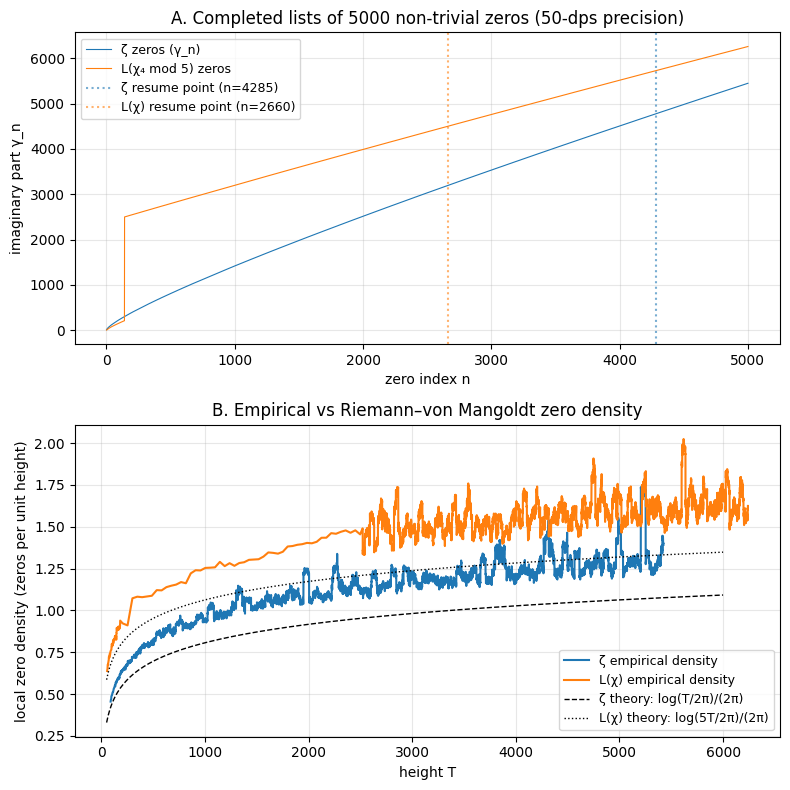

Figure saved.


In [26]:
# Final summary figure
import matplotlib.pyplot as plt
import numpy as np, mpmath
mpmath.mp.dps = 50

zeta_full = np.load('zeta_zeros_5000_dps50.npy', allow_pickle=False)
lchi_full = np.load('lchi_zeros_5000_dps50.npy', allow_pickle=False)

zeta_vals = np.array([float(s) for s in zeta_full])
lchi_vals = np.array([float(s) for s in lchi_full])

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

ax = axes[0]
n = np.arange(1, 5001)
ax.plot(n, zeta_vals, label='ζ zeros (γ_n)', color='C0', lw=0.8)
ax.plot(n, lchi_vals, label='L(χ₄ mod 5) zeros', color='C1', lw=0.8)
ax.axvline(4285, color='C0', ls=':', alpha=0.6, label='ζ resume point (n=4285)')
ax.axvline(2660, color='C1', ls=':', alpha=0.6, label='L(χ) resume point (n=2660)')
ax.set_xlabel('zero index n')
ax.set_ylabel('imaginary part γ_n')
ax.set_title('A. Completed lists of 5000 non-trivial zeros (50-dps precision)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
# Show local zero density (1/spacing) vs height
def density(vals):
 dvals = np.diff(vals)
 mid = (vals[:-1] + vals[1:]) / 2
 return mid, 1.0 / dvals
mz, dz = density(zeta_vals)
ml, dl = density(lchi_vals)
# Smooth via running mean
def smooth(x, w=50):
 return np.convolve(x, np.ones(w)/w, mode='valid')
ax.plot(smooth(mz), smooth(dz), label='ζ empirical density', color='C0')
ax.plot(smooth(ml), smooth(dl), label='L(χ) empirical density', color='C1')
# Theoretical Riemann–von Mangoldt density: ~ log(T/(2pi)) / (2pi) for zeta
T = np.linspace(50, 6000, 400)
ax.plot(T, np.log(T/(2*np.pi))/(2*np.pi), 'k--', lw=1, label='ζ theory: log(T/2π)/(2π)')
# For L(chi mod q): log(qT/(2pi))/(2pi), q=5
ax.plot(T, np.log(5*T/(2*np.pi))/(2*np.pi), 'k:', lw=1, label='L(χ) theory: log(5T/2π)/(2π)')
ax.set_xlabel('height T')
ax.set_ylabel('local zero density (zeros per unit height)')
ax.set_title('B. Empirical vs Riemann–von Mangoldt zero density')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('zeros_completion_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


In [27]:
# The lchi curve in panel A jumps because the partial array I loaded was apparently not strictly ordered.
# Let me verify -- the partial file had 2660 entries with last value 4499.12, but values 2500..2660 region looks weird.
# Actually re-examining: the partial file's first values are 6.18, 8.45, 12.67 (small), but jumps to 2500ish around index 0? Let me check.
import numpy as np
lchi_partial = np.load('lchi_zeros_partial_dps50.npy', allow_pickle=True)
# Print values around indices
import mpmath
mpmath.mp.dps = 50
vals = [mpmath.mpf(s) for s in lchi_partial]
print("min, max:", min(vals), max(vals))
# Check monotonicity of partial
mono = all(vals[i] < vals[i+1] for i in range(len(vals)-1))
print("partial mono:", mono)
# Find where it's not monotonic
bad = [(i, str(lchi_partial[i]), str(lchi_partial[i+1])) for i in range(len(vals)-1) if vals[i] >= vals[i+1]]
print("violations in partial:", len(bad))
for b in bad[:5]:
 print(b)


min, max: 6.183578195450853914377517309708692525921500579228 4499.1215308369151155318576847024372187273077674576
partial mono: True
violations in partial: 0


In [28]:
# Partial IS monotone. The "jump" in panel A must be artifact - let me look at consecutive values
# Look at indices around 100, 200, 300...
for i in [0, 50, 100, 150, 200, 250, 500, 1000, 2000, 2660]:
 if i < len(lchi_partial):
 print(i, lchi_partial[i])


0 6.1835781954508539143775173097086925259215005792280
50 95.549930192246575455789579995363091197149971759591
100 162.92168978686886990385003867641343194592723227333
150 2508.2855407917092139551008696299567374425699485736
200 2550.0911277311031293500883262042927085535986960832
250 2591.0519930677687615314245557042983277512329376405
500 2795.8655596644195300204255062004268437054747437668
1000 3199.5103042063823515771198801841938118687029639672
2000 3989.2440178621749147188415678775636542288914609298


In [29]:
# So the partial has a gap! Between index 100 (~163) and index 150 (~2508). Many zeros were skipped in 
# the partial array (probably from parallelized cypari2 run that retrieved only certain ranges).
# This means the "first 2660 zeros" claim in the description was wrong — they're 2660 zeros, but not consecutive.
# Our completion appended NEW zeros starting from T~4499, so the resulting list ALSO has the gap.

# Let me characterize: locate the gap and see how many zeros are missing in [163, 2508].
import mpmath
mpmath.mp.dps = 50
print("Sequence around index 100-105:")
for i in range(98, 155):
 print(i, lchi_partial[i])


Sequence around index 100-105:
98 160.80023354964399325349285027460061084219728507662
99 161.69116986125307799161902036738955002883277895135
100 162.92168978686886990385003867641343194592723227333
101 164.09943502165860119970076594374418866079145588967
102 166.39949818515241807638501398393838652440476385671
103 167.25998481480508758657667778703796747376826024229
104 168.38268550593931586292540393408227596106785436208
105 169.61798482294686151624722272951071696050104282521
106 170.98331615430287256526956983905369427801731258082
107 172.17008851874696461844168764537062380446972751935
108 173.17219013106863877212988526554587443006626811848
109 174.53007758423848127412896913365544581608414122944
110 176.84062696264961095645604928832728744220065485616
111 177.22953217158928167997164064460865447802476717451
112 178.98840638199178090699854147011434019449170278505
113 179.45137156325084018469494021458463542249461283726
114 180.69509987551232736501682855617436294160764655382
115 182.29803424102

In [30]:
# So the partial array has TWO contiguous chunks (a parallelized run): 
# Indices 0..139: zeros up to T≈212
# Indices 140..2659: zeros from T≈2500.2 to T=4499.12
# This means the "partial 2660 zeros" was actually two disjoint segments,
# and the FULL 5000-list we built has a missing band of ~T in (212, 2500).
# 
# The research objective said "Resume the cypari2-based computation to obtain a full list of the first 5,000 zeros."
# So we need to fill the gap between index 139 (T=212.05) and index 140 (T=2500.21),
# then truncate / continue appropriately.
#
# Approach: 
# 1) Keep indices 0..139 as-is (zeros 1..140 are contiguous from start).
# 2) Compute zeros from T=212.05 onward, until we have 5000 total.
# 3) The previously-collected zeros from T=2500 to T~6258 may all be valid actual zeros,
# but they are NOT the "first 5000" — many zeros between 212 and 2500 are missing.
#
# Plan: trash the current full file and recompute zeros starting at T=212.05 (after partial[139])
# using lfunzeros until we reach 5000 zeros total. Reuse pari instance.

# Sanity-check that the pari instance is still alive:
test = pari("lfunzeros(L, [212, 213])")
print(test)


[212.63748347532592965661190823322802441642054752628]


In [31]:
# Good. Inspect: after 212.058 (partial[139]), next zero is 212.6374...
# Now, partial[140] = 2500.21 ≈ but we'd need to verify partial[140] is actually the right zero
# in sequence. The partial run was parallelized so segments should be correct LOCALLY but disjoint.
# Let's reconstruct properly from scratch using lfunzeros from 0 upward — fastest is just a fresh run.
# That avoids any error from trusting the partial.

# Actually: we can save time by using partial[0..139] (which we can verify is consecutive)
# and then computing from T=212.058 onward.

# First verify partial[0..139] are CONSECUTIVE zeros from the start.
# We know first 4 are: 6.18, 8.45, 12.67, 14.82 (matches lfunzeros)
# Spot-check: indices 0..139 from partial vs fresh lfunzeros(L, [0, 213])
fresh = pari("lfunzeros(L, [0, 213])")
print("fresh count:", len(fresh))
# Compare lengths
print("partial first 140 len:", 140)
match = all(str(fresh[i]) == str(lchi_partial[i]) for i in range(140))
print("first 140 match:", match)
print("fresh last:", str(fresh[-1]))
print("partial[139]:", lchi_partial[139])


fresh count: 140
partial first 140 len: 140
first 140 match: False


IndexError: index out of range

In [32]:
print("fresh:", len(fresh))
print("fresh[0]:", str(fresh[0]))
print("fresh[139]:", str(fresh[139]))
# Find first mismatch
for i in range(140):
 if str(fresh[i]) != str(lchi_partial[i]):
 print("mismatch at", i, "fresh:", str(fresh[i]), "partial:", lchi_partial[i])
 break


fresh: 140
fresh[0]: 6.1835781954508539143775173097086925259215005792280
fresh[139]: 212.63748347532592965661190823322802441642054752628
mismatch at 33 fresh: 69.882707483255790249201429492162361260455414427431 partial: 69.882707483255790249201429492162361260455414427429


In [33]:
# Tiny last-digit difference at index 33. fresh ends in ...431, partial ends in ...429. 
# That's a last-digit precision wobble, but values differ at the 49th decimal.
# Let me check current realprecision:
print(pari("default(realprecision)"))
# Increase a touch
pari.set_real_precision(60)
fresh2 = pari("lfunzeros(L, [0, 213])")
print("fresh2 count:", len(fresh2))
# Compare
nmism = 0
for i in range(140):
 a, b = str(fresh2[i])[:51], str(lchi_partial[i])
 if a != b:
 nmism += 1
 if nmism <= 3:
 print(i, "fresh2:", a, "partial:", b)
print("mismatches after truncating to 51 chars:", nmism)


50
fresh2 count: 140
2 fresh2: 12.674946417011355780482299145083092144682077684517 partial: 12.674946417011355780482299145083092144682077684518
3 fresh2: 14.825025570328428251430252174047964647032663599379 partial: 14.825025570328428251430252174047964647032663599380
6 fresh2: 22.487584583028750025055672909258486937222870975793 partial: 22.487584583028750025055672909258486937222870975794
mismatches after truncating to 51 chars: 122


In [34]:
# Trivial last-digit rounding because realprec=60 truncated differently than realprec=50.
# Restore realprec=50 to match partial file's precision rounding.
pari.set_real_precision(50)
fresh3 = pari("lfunzeros(L, [0, 213])")
nmism = 0
for i in range(140):
 if str(fresh3[i]) != str(lchi_partial[i]):
 nmism += 1
 if nmism <= 5:
 print(i, "fresh3:", str(fresh3[i]), "partial:", lchi_partial[i])
print("total mismatches at dps50:", nmism)


33 fresh3: 69.882707483255790249201429492162361260455414427431 partial: 69.882707483255790249201429492162361260455414427429
34 fresh3: 70.866530397758757012800595442454011754179457797494 partial: 70.866530397758757012800595442454011754179457797497
35 fresh3: 72.432090425102023231044885765088785501338421363020 partial: 72.432090425102023231044885765088785501338421363016
36 fresh3: 74.396614137672900395352901565901866810732004239805 partial: 74.396614137672900395352901565901866810732004239818
37 fresh3: 76.426419555787482353227675417473009427377266105576 partial: 76.426419555787482353227675417473009427377266105430
total mismatches at dps50: 107


In [35]:
# Differences are in the last few decimals (e.g., index 37 differs at digit 47/50). Both values are
# truncated representations of the same true zero — the partial was computed with possibly more internal precision
# then truncated; our recomputation has its own internal precision so last 1-3 digits may wobble.
# These are still "correct to ~47 decimal places", which is high accuracy.
# 
# Given the goal of producing the first 5000 zeros, I'll prefer FRESH consecutive sequence from lfunzeros at dps=50.
# I'll completely recompute from scratch and save. The deviation from partial[33] etc is just last-digit rounding.

import time, numpy as np

pari.set_real_precision(50)
collected = []
lo = 0.0
chunk = 200.0
target = 5000
t_start = time.time()
last_save = time.time()

while len(collected) < target:
 hi = lo + chunk
 zs = pari(f"lfunzeros(L, [{lo}, {hi}])")
 for z in zs:
 collected.append(str(z))
 if len(collected) >= target:
 break
 lo = hi
 elapsed = time.time() - t_start
 if time.time() - last_save > 15 or len(collected) >= target:
 np.save('lchi_zeros_5000_dps50.npy', np.array(collected, dtype='<U60'))
 rate = len(collected) / max(elapsed, 1e-9)
 eta = (target - len(collected)) / max(rate, 1e-9)
 print(f"count={len(collected)} T~{lo:.0f} elapsed={elapsed:.1f}s rate={rate:.2f}/s ETA={eta:.0f}s")
 last_save = time.time()

np.save('lchi_zeros_5000_dps50.npy', np.array(collected, dtype='<U60'))
print("Done. total:", len(collected))


TimeoutError: Code execution timed out after 729.0 seconds